In [2]:
import os
import random
os.environ['PYTHONHASHSEED'] = '42'

import pandas as pd
import numpy as np
np.random.seed(42)
random.seed(42)

import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện tiền xử lý và mô hình
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score, roc_auc_score, recall_score
from sklearn.ensemble import RandomForestClassifier

# Các thuật toán yêu cầu
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

import tensorflow as tf
tf.random.set_seed(42)

# Tắt cảnh báo để giao diện sạch sẽ
import warnings
warnings.filterwarnings('ignore')
# Đọc dữ liệu (Đảm bảo bạn đã upload file lên Colab hoặc cùng thư mục)
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
# 1. Xử lý giá trị thiếu cho BMI
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
# 2. Loại bỏ cột ID
df.drop(['id'], axis=1, inplace=True)
# 3. Mã hóa biến phân loại (Categorical to Numerical)
# Chuyển đổi các cột chữ thành các cột số 0 và 1
df = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)
# 4. Tách đặc trưng (X) và nhãn (y)
X = df.drop('stroke', axis=1)
y = df['stroke']
# 5. Chia tập Train/Test
# Train: 70%
# Validation: 15%
# Test: 15%

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)
# 6. Xử lý mất cân bằng bằng SMOTE (Tạo thêm dữ liệu cho nhóm thiểu số)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)# 7. Chuẩn hóa dữ liệu (Bắt buộc cho SVM và Neural Network)
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Kích thước tập huấn luyện sau khi SMOTE: {X_train_res.shape}")
def fitness_function(individual, X_tr, y_tr, X_te, y_te):
    selected = [i for i, bit in enumerate(individual) if bit == 1]
    if len(selected) == 0: return 0
    # Dùng Decision Tree để đánh giá nhanh "độ tốt" của bộ đặc trưng
    model = DecisionTreeClassifier(max_depth=5, random_state=42)
    model.fit(X_tr[:, selected], y_tr)
    preds = model.predict(X_te[:, selected])

    f1 = f1_score(y_te, preds)

    # Penalty for too many features
    penalty = len(selected) / X_tr.shape[1]

    # fitness = 0.97 * f1 - 0.03 * penalty
    fitness = f1 - 0.02 * penalty

    return fitness

def run_ga(X_tr, y_tr, X_te, y_te, n_features):
    # Thiết lập seed trước GA để đảm bảo kết quả không thay đổi
    np.random.seed(42)
    
    pop_size = 20
    generations = 15
    mutation_rate = 0.03
    # Khởi tạo quần thể ngẫu nhiên
    population = np.random.randint(0, 2, (pop_size, n_features))
    
    for g in range(generations):
        scores = [fitness_function(ind, X_tr, y_tr, X_te, y_te) for ind in population]
        # Chọn lọc các cá thể tốt nhất
        best_indices = np.argsort(scores)[-pop_size//2:]
        parents = population[best_indices]
        
        # Tạo thế hệ mới qua lai ghép
        offspring = []
        for i in range(pop_size - len(parents)):
            p1, p2 = parents[np.random.randint(0, len(parents), 2)]
            child = np.where(np.random.rand(n_features) > 0.5, p1, p2)
            # Mutation
            for j in range(n_features):
                if np.random.rand() < mutation_rate:
                    child[j] = 1 - child[j]
            offspring.append(child)
        
        population = np.vstack([parents, offspring])
        print(f"Gen {g+1}: Best F1 = {max(scores):.4f}")

    final_scores = [
        fitness_function(ind, X_tr, y_tr, X_te, y_te)
        for ind in population
    ]

    best_individual = population[np.argmax(final_scores)]
    
    return best_individual

# Chạy GA để chọn đặc trưng
best_mask = run_ga(X_train_res, y_train_res, X_val, y_val, X_train_res.shape[1])
selected_features_idx = [i for i, bit in enumerate(best_mask) if bit == 1]

selected_feature_names = X.columns[selected_features_idx].tolist()
print(f"Các đặc trưng được chọn: {selected_feature_names}")
print(f"Số lượng đặc trưng tối ưu được chọn: {len(selected_features_idx)}")
# Lọc lại dữ liệu theo GA
X_train_ga = X_train_res[:, selected_features_idx]
X_test_ga = X_test[:, selected_features_idx]
X_val_ga = X_val[:, selected_features_idx]

models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, C=10, gamma=0.01, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_ga, y_train_res)
    # y_pred = model.predict(X_test_ga)
    y_probs = model.predict_proba(X_test_ga)[:, 1]

    threshold = 0.45

    y_pred = (y_probs > threshold).astype(int)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_probs))
    
# Thiết lập seed trước Neural Network để đảm bảo reproducible
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(len(selected_features_idx),)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid') # Phân loại nhị phân
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Huấn luyện
history = nn_model.fit(X_train_ga, y_train_res, epochs=50, batch_size=32, validation_data=(X_val_ga, y_val), verbose=1, callbacks=[early_stop])

nn_probs = nn_model.predict(X_test_ga)
threshold = 0.45
# Dự đoán
nn_preds = (nn_probs > threshold).astype(int)
print("\n--- Neural Network ---")
print(classification_report(y_test, nn_preds))
print("ROC-AUC:", roc_auc_score(y_test, nn_probs))

Kích thước tập huấn luyện sau khi SMOTE: (6806, 16)
Gen 1: Best F1 = 0.2400
Gen 2: Best F1 = 0.2400
Gen 3: Best F1 = 0.2400
Gen 4: Best F1 = 0.2546
Gen 5: Best F1 = 0.2546
Gen 6: Best F1 = 0.2546
Gen 7: Best F1 = 0.2546
Gen 8: Best F1 = 0.2546
Gen 9: Best F1 = 0.2546
Gen 10: Best F1 = 0.2546
Gen 11: Best F1 = 0.2546
Gen 12: Best F1 = 0.2547
Gen 13: Best F1 = 0.2547
Gen 14: Best F1 = 0.2547
Gen 15: Best F1 = 0.2547
Các đặc trưng được chọn: ['age', 'avg_glucose_level', 'gender_Male', 'gender_Other', 'work_type_Private', 'Residence_type_Urban', 'smoking_status_smokes']
Số lượng đặc trưng tối ưu được chọn: 7

--- Naive Bayes ---
              precision    recall  f1-score   support

           0       1.00      0.17      0.28       729
           1       0.06      1.00      0.11        38

    accuracy                           0.21       767
   macro avg       0.53      0.58      0.20       767
weighted avg       0.95      0.21      0.28       767

ROC-AUC: 0.7852862609197893

--- Decisio

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step


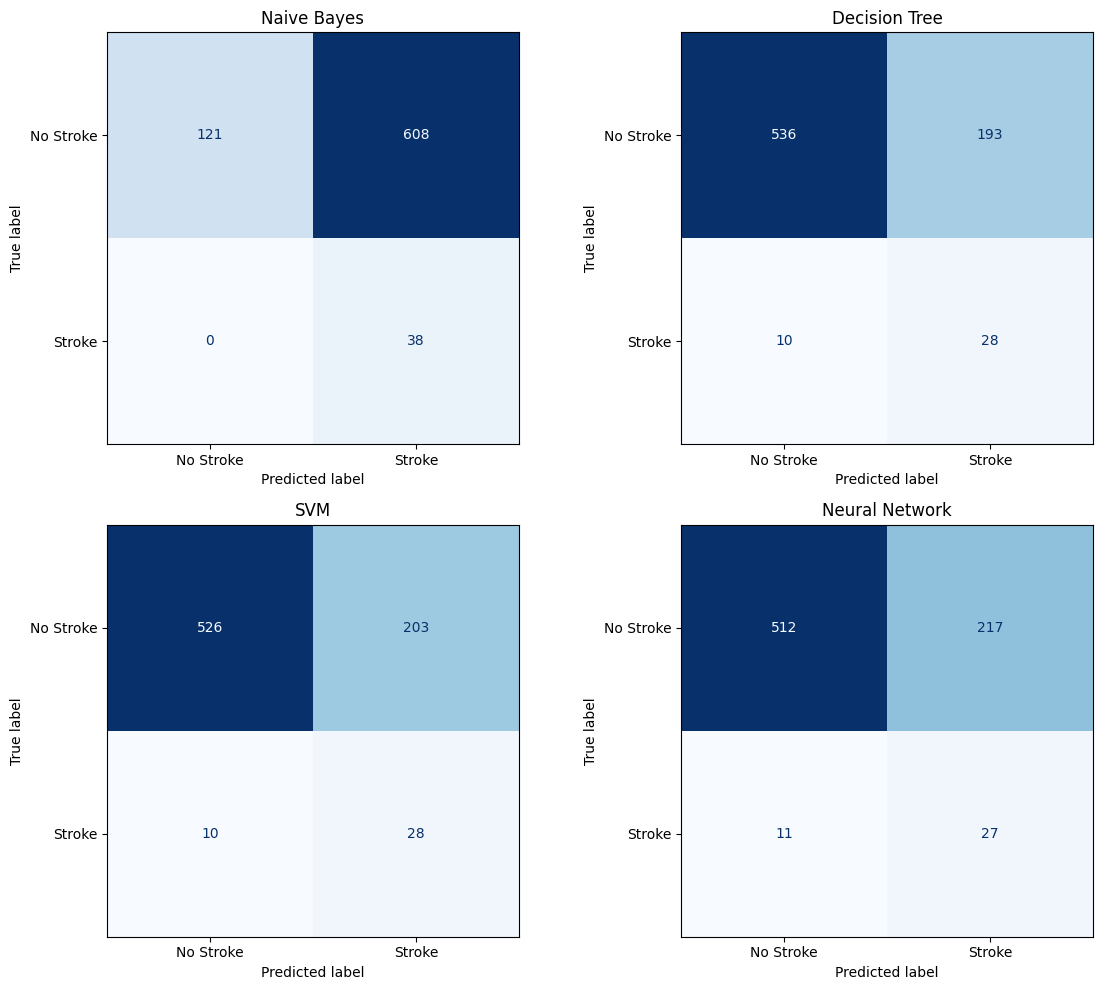

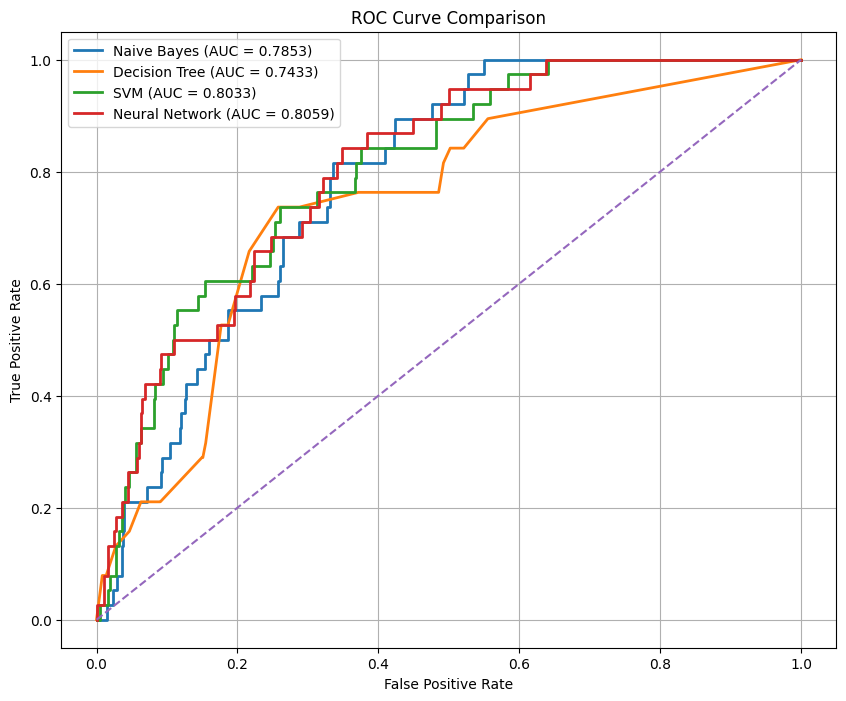


========== AUC SCORES ==========
Naive Bayes: 0.7853
Decision Tree: 0.7433
SVM: 0.8033
Neural Network: 0.8059

False Positives: 193
False Negatives: 10

===== FALSE NEGATIVE SAMPLES =====


,age,avg_glucose_level,gender_Male,gender_Other,work_type_Private,Residence_type_Urban,smoking_status_smokes
57,-0.324314,-0.788598,-1.063424,-0.012122,0.684392,0.786969,-0.545089
168,0.088389,-0.700031,0.940359,-0.012122,-1.461151,0.786969,-0.545089
176,-0.737018,-0.353128,-1.063424,-0.012122,-1.461151,0.786969,1.834562
258,-0.737018,-0.620486,-1.063424,-0.012122,0.684392,0.786969,-0.545089
363,-0.599450,-0.617356,0.940359,-0.012122,0.684392,-1.270699,-0.545089



===== FALSE POSITIVE SAMPLES =====


,age,avg_glucose_level,gender_Male,gender_Other,work_type_Private,Residence_type_Urban,smoking_status_smokes
0,1.097220,-0.945477,-1.063424,-0.012122,0.684392,0.786969,-0.545089
4,-0.232603,0.064481,0.940359,-0.012122,0.684392,0.786969,-0.545089
5,0.363525,1.946669,0.940359,-0.012122,0.684392,0.786969,-0.545089
6,0.822084,-0.685853,-1.063424,-0.012122,-1.461151,-1.270699,-0.545089
17,0.363525,-0.340239,0.940359,-0.012122,0.684392,-1.270699,-0.545089


                 Feature  Importance
0                    age    0.769833
1      avg_glucose_level    0.076221
4      work_type_Private    0.061750
6  smoking_status_smokes    0.041870
2            gender_Male    0.039161
5   Residence_type_Urban    0.011165
3           gender_Other    0.000000


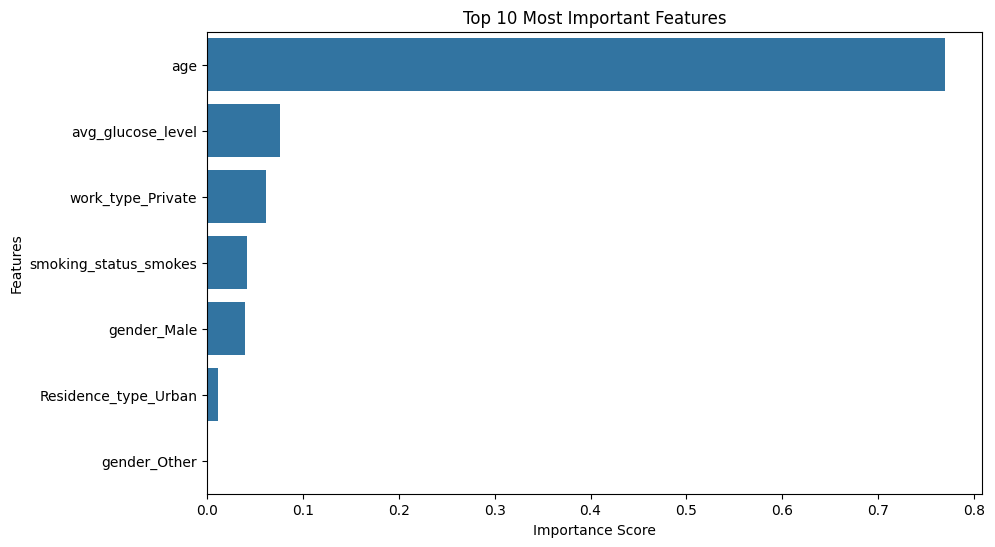

In [3]:
# ============================================
# IMPORT THÊM THƯ VIỆN
# ============================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# ============================================
# LƯU KẾT QUẢ CÁC MODEL
# ============================================

results = {}

# Machine Learning models
for name, model in models.items():

    y_probs = model.predict_proba(X_test_ga)[:, 1]
    y_pred = (y_probs > threshold).astype(int)

    results[name] = {
        "y_pred": y_pred,
        "y_probs": y_probs
    }

# Neural Network
nn_probs = nn_model.predict(X_test_ga).ravel()
nn_preds = (nn_probs > threshold).astype(int)

results["Neural Network"] = {
    "y_pred": nn_preds,
    "y_probs": nn_probs
}
# ============================================
# CONFUSION MATRIX
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):

    cm = confusion_matrix(y_test, result["y_pred"])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Stroke", "Stroke"]
    )

    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)

    axes[idx].set_title(f"{name}")

plt.tight_layout()
plt.show()
# ============================================
# ROC CURVE + AUC
# ============================================

plt.figure(figsize=(10, 8))

auc_scores = {}

for name, result in results.items():

    fpr, tpr, _ = roc_curve(y_test, result["y_probs"])

    roc_auc = auc(fpr, tpr)

    auc_scores[name] = roc_auc

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.4f})"
    )

# Đường random
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()
# ============================================
# HIỂN THỊ AUC
# ============================================

print("\n========== AUC SCORES ==========")

for name, score in auc_scores.items():
    print(f"{name}: {score:.4f}")
    # ============================================
# ERROR ANALYSIS
# ============================================

best_model_name = "Decision Tree"

y_pred_best = results[best_model_name]["y_pred"]

# False Positive
fp_idx = np.where((y_test == 0) & (y_pred_best == 1))[0]

# False Negative
fn_idx = np.where((y_test == 1) & (y_pred_best == 0))[0]

print(f"\nFalse Positives: {len(fp_idx)}")
print(f"False Negatives: {len(fn_idx)}")
# Convert lại DataFrame để dễ xem
X_test_df = pd.DataFrame(
    X_test_ga,
    columns=selected_feature_names
)

# False Negative samples
print("\n===== FALSE NEGATIVE SAMPLES =====")
display(X_test_df.iloc[fn_idx[:5]])

# False Positive samples
print("\n===== FALSE POSITIVE SAMPLES =====")
display(X_test_df.iloc[fp_idx[:5]])
# ============================================
# FEATURE IMPORTANCE
# ============================================

dt_model = models["Decision Tree"]

importances = dt_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": selected_feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df.head(10))
# ============================================
# FEATURE IMPORTANCE PLOT
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(10)
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()
